# Overfitting và Các phương pháp khắc phục
**Công thức đánh giá hàm Train Error và Test Error (Mean Squared Error - MSE):**
- Train Error: $$MSE_{train} = \frac{1}{N_{train}} \sum_{i=1}^{N_{train}} (y_i - \hat{y}_i)^2$$
- Test Error: $$MSE_{test} = \frac{1}{N_{test}} \sum_{i=1}^{N_{test}} (y_i - \hat{y}_i)^2$$

---
## 1. Hiện tượng Overfitting (Quá khớp)
Overfitting xảy ra khi mô hình học máy học quá chi tiết cả những tín hiệu nhiễu của dữ liệu huấn luyện, khiến nó đạt kết quả rất tốt trên tập Train nhưng lại dự đoán kém trên tập dữ liệu mới (Test).
Đoạn mã sau minh họa mô hình hồi quy đa thức bậc cao (bậc 18) đang cố bám theo từng điểm dữ liệu, gây ra Overfitting.

ĐÁNH GIÁ MÔ HÌNH HỒI QUY ĐA THỨC BẬC 18:
 - Train Error (MSE): 361.54
 - Test Error (MSE):  1131977677400.36


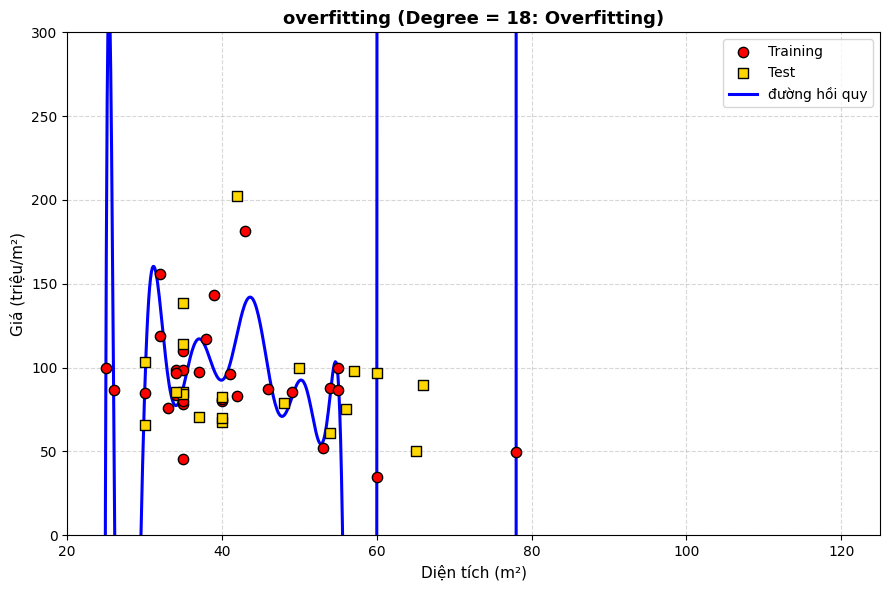

In [13]:
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

def clean_num(val):
  if pd.isna(val):
    return np.nan
  val = str(val).replace(',', '.')
  m = re.search(r'[-+]?\d*\.\d+|\d+', val)
  return float(m.group()) if m else np.nan

df = pd.read_csv('data.csv')
df['area'] = df['Diện tích'].apply(clean_num)
df['price_m2'] = df['Giá/m2'].apply(clean_num)

data = df[['area', 'price_m2']].dropna()
data = data[
    (data['area'] >= 25) & (data['area'] <= 120)
    & (data['price_m2'] >= 30) & (data['price_m2'] <= 220)
]

sample_data = data.sample(n=50, random_state=42)
X = sample_data[['area']]
y = sample_data['price_m2']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=30, test_size=20, random_state=42
)

degree = 18
model = make_pipeline(PolynomialFeatures(degree=degree), StandardScaler(), LinearRegression())
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)


train_error = np.mean((y_train.values.flatten() - train_pred.flatten())**2)
test_error = np.mean((y_test.values.flatten() - test_pred.flatten())**2)

print('=' * 50)
print(f'ĐÁNH GIÁ MÔ HÌNH HỒI QUY ĐA THỨC BẬC {degree}:')
print(f' - Train Error (MSE): {train_error:.2f}')
print(f' - Test Error (MSE):  {test_error:.2f}')
print('=' * 50)

plt.figure(figsize=(9, 6))
x_min, x_max = X['area'].min() - 2, X['area'].max() + 2
x_plot = pd.DataFrame({'area': np.linspace(x_min, x_max, 500)})
y_plot = model.predict(x_plot)
plt.scatter(X_train, y_train, color='red', edgecolors='black', s=55, label='Training', zorder=5)
plt.scatter(X_test, y_test, color='gold', marker='s', edgecolors='black', s=55, label='Test', zorder=5)
plt.plot(x_plot, y_plot, color='blue', linewidth=2.2, label='đường hồi quy')
plt.ylim(0, 300)
plt.xlim(20, 125)
plt.title(f'overfitting (Degree = {degree}: Overfitting)', fontsize=13, fontweight='bold')
plt.xlabel('Diện tích (m²)', fontsize=11)
plt.ylabel('Giá (triệu/m²)', fontsize=11)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Cách 1: Thêm dữ liệu huấn luyện (More Data)
Khi mô hình quá phức tạp, có quá ít dữ liệu sẽ khiến mô hình ghi nhớ thuộc lòng thay vì học quy luật chung. Bổ sung thêm nhiều dữ liệu huấn luyện sẽ làm mượt đường hồi quy và giảm hiện tượng quá khớp hiệu quả.

In [14]:
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    data[['area']], data['price_m2'], test_size=0.2, random_state=42
)

sample_sizes = [30, 60, 120, 250, len(X_train_full)]
degree = 8

print('{:<18} | {:<18} | {:<18}'.format('So luong mau (N)', 'Train MSE', 'Test MSE'))
print('-' * 60)

for n in sample_sizes:
  X_sub = X_train_full.iloc[:n]
  y_sub = y_train_full.iloc[:n]

  model = make_pipeline(PolynomialFeatures(degree=degree), StandardScaler(), LinearRegression())
  model.fit(X_sub, y_sub)


  tr_err = np.mean((y_sub.values.flatten() - model.predict(X_sub).flatten())**2)
  te_err = np.mean((y_test_full.values.flatten() - model.predict(X_test_full).flatten())**2)

  print('{:<18} | {:<18.2f} | {:<18.2f}'.format(n, tr_err, te_err))


So luong mau (N)   | Train MSE          | Test MSE          
------------------------------------------------------------
30                 | 1214.59            | 4624728267.89     
60                 | 1075.90            | 5676678.02        
120                | 1042.62            | 9497.55           
250                | 981.91             | 1304.19           
59261              | 1032.64            | 1039.14           


## Cách 2: Chia tập Validation (Validation Fix)
Thay vì sử dụng trực tiếp tập Test để điều chỉnh tham số (chọn bậc đa thức), ta tách dữ liệu thành 3 phần: Train, Validation và Test. Ta dùng tập Validation để tìm ra cấu hình tốt nhất, giữ cho tập Test luôn là dữ liệu chưa từng thấy để đánh giá độ chính xác cuối cùng một cách trung thực nhất.

In [15]:
sample_data = data.sample(n=60, random_state=42)
X = sample_data[['area']]
y = sample_data['price_m2']

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=10, random_state=42)

print('{:<10} | {:<18} | {:<22} | {:<18}'.format('Bac (d)', 'Train Error', 'Val Error', 'Test Error'))
print('-' * 75)

val_errors = []
for d in range(1, 6):
  model = make_pipeline(PolynomialFeatures(degree=d), StandardScaler(), LinearRegression())
  model.fit(X_train, y_train)

 
  tr_err = np.mean((y_train.values.flatten() - model.predict(X_train).flatten())**2)
  va_err = np.mean((y_val.values.flatten() - model.predict(X_val).flatten())**2)
  te_err = np.mean((y_test.values.flatten() - model.predict(X_test).flatten())**2)

  val_errors.append(va_err)
  print(f'{d:<10} | {tr_err:<18.2f} | {va_err:<22.2f} | {te_err:<18.2f}')

best_degree = np.argmin(val_errors) + 1
print('-' * 75)
print(f'=> BẬC TỐI ƯU ĐƯỢC CHỌN: d = {best_degree}')


Bac (d)    | Train Error        | Val Error              | Test Error        
---------------------------------------------------------------------------
1          | 1366.83            | 682.13                 | 583.60            
2          | 1234.68            | 656.72                 | 648.77            
3          | 1195.68            | 749.17                 | 694.11            
4          | 1151.68            | 737.13                 | 752.14            
5          | 925.64             | 1316.21                | 1104.98           
---------------------------------------------------------------------------
=> BẬC TỐI ƯU ĐƯỢC CHỌN: d = 2


## Cách 3: K-Fold Cross Validation
Khi lượng dữ liệu nhỏ, việc chia ra một tập validation cố định có thể gây sai lệch ngẫu nhiên. K-Fold Cross Validation chia dữ liệu làm K phần, luân phiên train trên K-1 phần và validate trên 1 phần còn lại. Bằng cách tính trung bình lỗi của K lần, kết quả thu được phản ánh chính xác hơn hiệu năng của mô hình.

In [16]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
degrees = list(range(1, 9))
cv_val_scores = []

print('{:<10} | {:<18} | {:<22} | {:<18}'.format('Bac (d)', 'Train MSE (TB)', 'CV Val MSE (5-Fold)', 'Test MSE'))
print('-' * 75)

for d in degrees:
  fold_tr_errs = []
  fold_va_errs = []
  for tr_idx, va_idx in kf.split(X_train_val):
    X_tr, X_va = X_train_val.iloc[tr_idx], X_train_val.iloc[va_idx]
    y_tr, y_va = y_train_val.iloc[tr_idx], y_train_val.iloc[va_idx]

    model = make_pipeline(PolynomialFeatures(degree=d), StandardScaler(), LinearRegression())
    model.fit(X_tr, y_tr)

  
    fold_tr_errs.append(np.mean((y_tr.values.flatten() - model.predict(X_tr).flatten())**2))
    fold_va_errs.append(np.mean((y_va.values.flatten() - model.predict(X_va).flatten())**2))

  mean_tr_err = np.mean(fold_tr_errs)
  mean_va_err = np.mean(fold_va_errs)
  cv_val_scores.append(mean_va_err)

  full_model = make_pipeline(PolynomialFeatures(degree=d), StandardScaler(), LinearRegression())
  full_model.fit(X_train_val, y_train_val)
  te_err = np.mean((y_test.values.flatten() - full_model.predict(X_test).flatten())**2)

  print('{:<10} | {:<18.2f} | {:<22.2f} | {:<18.2f}'.format(d, mean_tr_err, mean_va_err, te_err))

best_degree = degrees[np.argmin(cv_val_scores)]
print('-' * 75)
print('=> BAC TOI UU (CV 5-FOLD): d =', best_degree)


Bac (d)    | Train MSE (TB)     | CV Val MSE (5-Fold)    | Test MSE          
---------------------------------------------------------------------------
1          | 1181.76            | 1279.88                | 557.00            
2          | 1075.89            | 1191.92                | 629.72            
3          | 1060.41            | 1193.55                | 637.36            
4          | 1022.96            | 1230.42                | 698.08            
5          | 933.61             | 1217.17                | 857.68            
6          | 883.13             | 3805.26                | 867.28            
7          | 789.69             | 6313.76                | 1198.62           
8          | 761.89             | 655512.71              | 1213.67           
---------------------------------------------------------------------------
=> BAC TOI UU (CV 5-FOLD): d = 2


## Cách 4: Regularization 
Regularization phạt các trọng số lớn trong mô hình bằng cách cộng thêm hệ số phạt (alpha) vào hàm Loss. Điều này ép các biến số học ít nhiễu đi, giúp hàm hồi quy trở nên mượt hơn và giảm mạnh rủi ro Overfitting ngay cả khi số lượng đặc trưng đa thức là rất lớn.

In [17]:
from sklearn.linear_model import Ridge

alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
val_errors_ridge = []

print('{:<10} | {:<18} | {:<18} | {:<18}'.format('Alpha', 'Train Error', 'Val Error', 'Test Error'))
print('-' * 72)

for a in alphas:
  model = make_pipeline(PolynomialFeatures(degree=8), StandardScaler(), Ridge(alpha=a))
  model.fit(X_train, y_train)

  
  tr_err = np.mean((y_train.values.flatten() - model.predict(X_train).flatten())**2)
  va_err = np.mean((y_val.values.flatten() - model.predict(X_val).flatten())**2)
  te_err = np.mean((y_test.values.flatten() - model.predict(X_test).flatten())**2)

  val_errors_ridge.append(va_err)
  print('{:<10} | {:<18.2f} | {:<18.2f} | {:<18.2f}'.format(a, tr_err, va_err, te_err))

best_alpha = alphas[np.argmin(val_errors_ridge)]
print('-' * 72)
print('=> HỆ SỐ PHẠT TỐI ƯU: alpha =', best_alpha)


Alpha      | Train Error        | Val Error          | Test Error        
------------------------------------------------------------------------
0.001      | 1162.00            | 753.67             | 720.01            
0.01       | 1179.78            | 731.63             | 703.91            
0.1        | 1189.81            | 686.54             | 667.63            
1.0        | 1249.97            | 621.23             | 618.44            
10.0       | 1291.73            | 608.60             | 606.81            
100.0      | 1315.19            | 635.06             | 597.22            
1000.0     | 1382.45            | 760.79             | 602.76            
------------------------------------------------------------------------
=> HỆ SỐ PHẠT TỐI ƯU: alpha = 10.0


## Cách 5: Dừng sớm (Early Stopping)
Đối với các mô hình sử dụng quá trình học lặp đi lặp lại như Gradient Descent (Mạng nơ-ron, Linear Regression lặp), nếu train qua quá nhiều epoch (kỷ nguyên), mô hình sẽ dần ghi nhớ nhiễu và Overfitting. Dừng sớm là thuật toán liên tục theo dõi lỗi trên tập Validation, và ngay khi lỗi này có dấu hiệu tăng trở lại, quá trình huấn luyện sẽ bị ép dừng lại ngay lập tức.

In [18]:
poly = PolynomialFeatures(degree=8, include_bias=False)
scaler = StandardScaler()

X_tr = scaler.fit_transform(poly.fit_transform(X_train))
X_va = scaler.transform(poly.transform(X_val))
X_te = scaler.transform(poly.transform(X_test))

N_tr = len(X_tr)
X_tr_b = np.c_[np.ones(N_tr), X_tr]
X_va_b = np.c_[np.ones(len(X_va)), X_va]
X_te_b = np.c_[np.ones(len(X_te)), X_te]

np.random.seed(42)
w = np.zeros(X_tr_b.shape[1])
learning_rate = 0.05
epochs = 1500

prev_val_err = float('inf')
best_epoch = None

print('{:<10} | {:<20} | {:<20} | {:<20}'.format('Epoch', 'Train Error (MSE)', 'Val Error (MSE)', 'Test Error (MSE)'))
print('-' * 75)

for ep in range(1, epochs + 1):
  pred_tr = X_tr_b @ w
  grad = (2 / N_tr) * (X_tr_b.T @ (pred_tr - y_train.values))
  w = w - learning_rate * grad


  tr_err = np.mean((y_train.values.flatten() - pred_tr.flatten())**2)
  va_err = np.mean((y_val.values.flatten() - (X_va_b @ w).flatten())**2)
  te_err = np.mean((y_test.values.flatten() - (X_te_b @ w).flatten())**2)

  if ep % 50 == 0 or ep == 1 or ep in [152, 153, 154]:
    print(f'{ep:<10} | {tr_err:<20.2f} | {va_err:<20.2f} | {te_err:<20.2f}')

  if va_err > prev_val_err:
    best_epoch = ep - 1
    print('-' * 75)
    print(f'=> DỪNG SỚM TẠI EPOCH {best_epoch} (Do Val Error bắt đầu tăng ở Epoch {ep})')
    break
  else:
    prev_val_err = va_err


Epoch      | Train Error (MSE)    | Val Error (MSE)      | Test Error (MSE)    
---------------------------------------------------------------------------
1          | 10727.83             | 7556.85              | 6426.75             
---------------------------------------------------------------------------
=> DỪNG SỚM TẠI EPOCH 36 (Do Val Error bắt đầu tăng ở Epoch 37)
